# 01 — Extracción de Features de Audio
### Freesound Audio Tagging 2019

Este cuadernillo convierte cada archivo `.wav` en un **vector numérico** (features),
que es exactamente la matriz `X` que usamos en el cuadernillo base con K-Means y GMM.


## 1. Instalación de dependencias

In [16]:
import os
import numpy as np
import pandas as pd
import librosa
import pickle
from pathlib import Path
from tqdm import tqdm
import IPython.display as ipd
from sklearn.preprocessing import LabelEncoder

DATASET_PATH = Path(r"C:\Universidad\SIS_420\Datasets\freesound-audio-tagging-2019")

CURATED_DIR   = DATASET_PATH / "train_curated"
NOISY_DIR     = DATASET_PATH / "train_noisy"
CURATED_CSV   = DATASET_PATH / "train_curated.csv"
NOISY_CSV     = DATASET_PATH / "train_noisy.csv"
FEATURES_DIR  = Path("features")
FEATURES_DIR.mkdir(exist_ok=True)

# Parámetros de audio
SR        = 22050   # Sample rate estándar
N_MFCC    = 40      # Número de coeficientes MFCC
MAX_SEC   = 10      # Recortamos audios a 10 segundos
MAX_LEN   = SR * MAX_SEC

print(f"Dataset:  {DATASET_PATH}")
print(f"Curated:  {CURATED_DIR}")
print(f"Noisy:    {NOISY_DIR}")
print(f"Features: {FEATURES_DIR.resolve()}")

Dataset:  C:\Universidad\SIS_420\Datasets\freesound-audio-tagging-2019
Curated:  C:\Universidad\SIS_420\Datasets\freesound-audio-tagging-2019\train_curated
Noisy:    C:\Universidad\SIS_420\Datasets\freesound-audio-tagging-2019\train_noisy
Features: C:\Universidad\SIS_420\Laboratorios\Laboratorio_07\punto2\features


## 2. Verificación rápida del dataset

In [17]:
df_curated = pd.read_csv(CURATED_CSV)
df_noisy   = pd.read_csv(NOISY_CSV)

print("=== train_curated.csv ===")
print(df_curated.head())
print(f"\nTotal archivos curated: {len(df_curated)}")

print("\n=== train_noisy.csv ===")
print(df_noisy.head())
print(f"\nTotal archivos noisy: {len(df_noisy)}")

=== train_curated.csv ===
          fname           labels
0  0006ae4e.wav             Bark
1  0019ef41.wav         Raindrop
2  001ec0ad.wav  Finger_snapping
3  0026c7cb.wav              Run
4  0026f116.wav  Finger_snapping

Total archivos curated: 4970

=== train_noisy.csv ===
          fname                                          labels
0  00097e21.wav                    Bathtub_(filling_or_washing)
1  000b6cfb.wav                                      Motorcycle
2  00116cd2.wav              Marimba_and_xylophone,Glockenspiel
3  00127d14.wav  Water_tap_and_faucet,Sink_(filling_or_washing)
4  0019adae.wav                                        Raindrop

Total archivos noisy: 19815


In [18]:
# Las etiquetas pueden ser múltiples por archivo 
df_curated["label_primary"] = df_curated["labels"].str.split(",").str[0].str.strip()
df_noisy["label_primary"]   = df_noisy["labels"].str.split(",").str[0].str.strip()

print("Clases únicas en curated:", df_curated["label_primary"].nunique())
print("\nTop 10 clases más frecuentes (curated):")
print(df_curated["label_primary"].value_counts().head(10))

Clases únicas en curated: 78

Top 10 clases más frecuentes (curated):
label_primary
Bark                      75
Raindrop                  75
Finger_snapping           75
Fart                      75
Knock                     75
Motorcycle                75
Burping_and_eructation    75
Female_singing            75
Zipper_(clothing)         75
Meow                      75
Name: count, dtype: int64


Archivo: 0006ae4e.wav
Duración: 7.04 segundos
Sample rate: 22050 Hz
Etiqueta: Bark


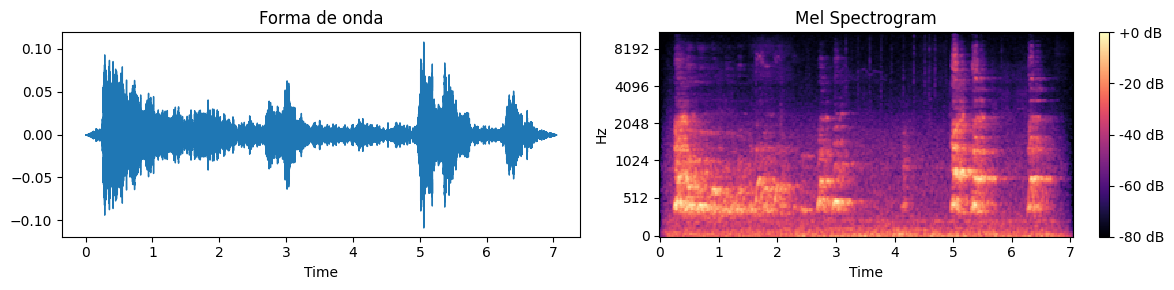

In [19]:
import matplotlib.pyplot as plt

# Verificar un audio de ejemplo
sample_file = CURATED_DIR / df_curated["fname"].iloc[0]
audio, sr = librosa.load(sample_file, sr=SR, mono=True)

print(f"Archivo: {sample_file.name}")
print(f"Duración: {len(audio)/sr:.2f} segundos")
print(f"Sample rate: {sr} Hz")
print(f"Etiqueta: {df_curated['label_primary'].iloc[0]}")

plt.figure(figsize=(12, 3))
plt.subplot(1, 2, 1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Forma de onda")

plt.subplot(1, 2, 2)
S = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel Spectrogram")
plt.tight_layout()
plt.show()
ipd.Audio(audio, rate=sr)

## 3. Función de extracción de features

Extraemos MFCCs estadísticos: para cada coeficiente calculamos media y desviación estándar sobre el tiempo.
Esto produce un vector de tamaño fijo (80 valores) sin importar cuánto dure el audio.


In [20]:
def extract_features(file_path, sr=SR, n_mfcc=N_MFCC, max_len=MAX_LEN):
    """
    Extrae MFCCs estadísticos de un archivo de audio.
    
    Retorna:
        np.array de shape (n_mfcc * 2,) = (80,)
        None si el archivo no se puede leer
    """
    try:
        # Cargar audio (mono, sample rate fijo)
        audio, _ = librosa.load(file_path, sr=sr, mono=True)
        
        # Recortar o rellenar hasta MAX_LEN
        if len(audio) > max_len:
            audio = audio[:max_len]
        else:
            audio = np.pad(audio, (0, max_len - len(audio)))
        
        # Calcular MFCCs: shape (n_mfcc, n_frames)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Estadísticas sobre el eje temporal → vector fijo
        features = np.hstack([
            mfcc.mean(axis=1),  # Media por coeficiente
            mfcc.std(axis=1),   # Desv. estándar por coeficiente
        ])
        return features
    
    except Exception as e:
        print(f"  Error en {file_path}: {e}")
        return None


# Prueba rápida
feat = extract_features(sample_file)
print(f"Shape del vector de features: {feat.shape}")
print(f"Primeros 10 valores: {feat[:10].round(3)}")

Shape del vector de features: (80,)
Primeros 10 valores: [-541.563  112.506    4.052    0.73    -2.324    9.836   -8.672    2.553
    1.67     1.507]


## 4. Extracción de train_curated (con etiquetas limpias)


In [21]:
# Codificador de etiquetas (texto → número)
le = LabelEncoder()
le.fit(df_curated["label_primary"])
print(f"Clases ({len(le.classes_)}): {list(le.classes_[:10])} ...")

# Guardar el codificador para usarlo en los otros cuadernillos
with open(FEATURES_DIR / "label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print("label_encoder.pkl guardado.")

Clases (78): ['Accelerating_and_revving_and_vroom', 'Accordion', 'Acoustic_guitar', 'Applause', 'Bark', 'Bass_drum', 'Bass_guitar', 'Bathtub_(filling_or_washing)', 'Bicycle_bell', 'Burping_and_eructation'] ...
label_encoder.pkl guardado.


In [ ]:
print("Extrayendo features de train_curated...")

# Evitar recomputar si ya existen en memoria
if "X_curated" in globals() and "y_curated" in globals():
    print("Features ya existen en memoria. No se recalculó.")
else:
    X_curated_list   = []
    y_curated_list   = []
    names_curated    = []
    errors_curated   = []

    for _, row in tqdm(df_curated.iterrows(), total=len(df_curated)):
        fpath = CURATED_DIR / row["fname"]
        feat  = extract_features(fpath)
        
        if feat is not None:
            X_curated_list.append(feat)
            y_curated_list.append(le.transform([row["label_primary"]])[0])
            names_curated.append(row["fname"])
        else:
            errors_curated.append(row["fname"])

    X_curated = np.array(X_curated_list)
    y_curated = np.array(y_curated_list)
    names_curated = np.array(names_curated)

    print(f"\nX_curated shape: {X_curated.shape}")
    print(f"y_curated shape: {y_curated.shape}")
    print(f"Archivos con error: {len(errors_curated)}")

Extrayendo features de train_curated...


100%|██████████| 4970/4970 [02:48<00:00, 29.44it/s]


X_curated shape: (4970, 80)
y_curated shape: (4970,)
Archivos con error: 0


In [ ]:
print("Guardando archivos...")

path_X     = FEATURES_DIR / "X_curated.npy"
path_y     = FEATURES_DIR / "y_curated.npy"
path_names = FEATURES_DIR / "file_names_curated.npy"

# X
if not os.path.exists(path_X):
    np.save(path_X, X_curated)
    print(f"  {path_X} → {X_curated.shape}")
else:
    print(f"[AVISO] Ya existe: {path_X} (no se sobrescribió)")

# y
if not os.path.exists(path_y):
    np.save(path_y, y_curated)
    print(f"  {path_y} → {y_curated.shape}")
else:
    print(f"[AVISO] Ya existe: {path_y} (no se sobrescribió)")

# nombres
if not os.path.exists(path_names):
    np.save(path_names, names_curated)
    print(f"  {path_names}")
else:
    print(f"[AVISO] Ya existe: {path_names} (no se sobrescribió)")

Archivos guardados:
  features/X_curated.npy        → (4970, 80)
  features/y_curated.npy        → (4970,)
  features/file_names_curated.npy


## 5. Extracción de train_noisy (datos "sin etiquetar")

En este trabajo tratamos a train_noisy como si no tuviéramos etiquetas.
Las etiquetas ruidosas las guardamos sólo como referencia para evaluar qué tan bien
funciona la propagación en el cuadernillo 03.


In [24]:
print("Extrayendo features de train_noisy...")

X_noisy_list  = []
y_noisy_list  = []   # etiquetas ruidosas (referencia)
names_noisy   = []
errors_noisy  = []

# Filtramos sólo las etiquetas que el codificador conoce (de curated)
known_labels = set(le.classes_)

for _, row in tqdm(df_noisy.iterrows(), total=len(df_noisy)):
    label_raw = row["label_primary"]
    fpath = NOISY_DIR / row["fname"]
    feat  = extract_features(fpath)
    
    if feat is not None:
        X_noisy_list.append(feat)
        # Guardar etiqueta numérica si es conocida, -1 si es nueva
        if label_raw in known_labels:
            y_noisy_list.append(le.transform([label_raw])[0])
        else:
            y_noisy_list.append(-1)
        names_noisy.append(row["fname"])
    else:
        errors_noisy.append(row["fname"])

X_noisy = np.array(X_noisy_list)
y_noisy = np.array(y_noisy_list)
names_noisy = np.array(names_noisy)

print(f"\nX_noisy shape: {X_noisy.shape}")
print(f"y_noisy shape: {y_noisy.shape}")
print(f"Archivos con error: {len(errors_noisy)}")

Extrayendo features de train_noisy...


100%|██████████| 19815/19815 [11:47<00:00, 28.01it/s]


X_noisy shape: (19815, 80)
y_noisy shape: (19815,)
Archivos con error: 0


In [25]:
np.save(FEATURES_DIR / "X_noisy.npy",        X_noisy)
np.save(FEATURES_DIR / "y_noisy_raw.npy",    y_noisy)
np.save(FEATURES_DIR / "file_names_noisy.npy", names_noisy)
print("Archivos guardados:")
print(f"  {FEATURES_DIR}/X_noisy.npy          → {X_noisy.shape}")
print(f"  {FEATURES_DIR}/y_noisy_raw.npy      → {y_noisy.shape}")
print(f"  {FEATURES_DIR}/file_names_noisy.npy")

Archivos guardados:
  features/X_noisy.npy          → (19815, 80)
  features/y_noisy_raw.npy      → (19815,)
  features/file_names_noisy.npy


## 6. Verificación y estadísticas finales

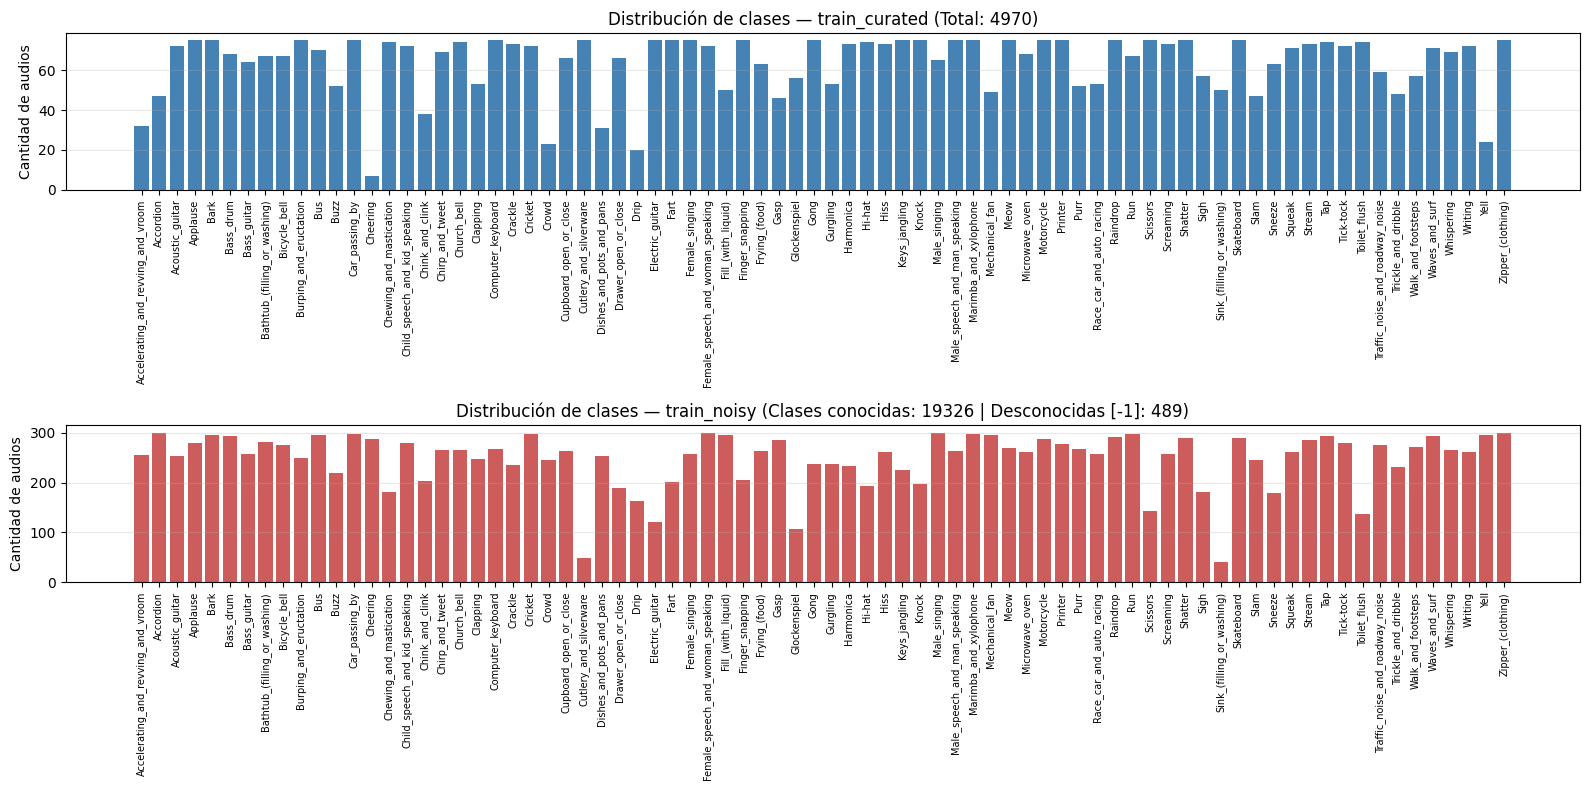

Total etiquetas en Noisy: 19815
Etiquetas mapeadas a clases conocidas: 19326
Etiquetas ignoradas (clases nuevas o -1): 489


In [26]:
unique_c, counts_c = np.unique(y_curated, return_counts=True)

mask_known = y_noisy >= 0
unique_n, counts_n = np.unique(y_noisy[mask_known], return_counts=True)
n_unknown = np.sum(y_noisy == -1)

plt.figure(figsize=(16, 8))

# --- Gráfico Curated ---
plt.subplot(2, 1, 1)
plt.bar(le.classes_[unique_c], counts_c, color='steelblue')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Cantidad de audios")
plt.title(f"Distribución de clases — train_curated (Total: {len(y_curated)})")
plt.grid(axis='y', alpha=0.3)

# --- Gráfico Noisy ---
plt.subplot(2, 1, 2)
plt.bar(le.classes_[unique_n], counts_n, color='indianred')
plt.xticks(rotation=90, fontsize=7)
plt.ylabel("Cantidad de audios")
plt.title(f"Distribución de clases — train_noisy (Clases conocidas: {len(y_noisy[mask_known])} | Desconocidas [-1]: {n_unknown})")
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Resumen numérico extra en consola
print(f"Total etiquetas en Noisy: {len(y_noisy)}")
print(f"Etiquetas mapeadas a clases conocidas: {len(y_noisy[mask_known])}")
print(f"Etiquetas ignoradas (clases nuevas o -1): {n_unknown}")

In [27]:
# Verificar que los valores no tienen NaN ni Inf
print("NaN en X_curated:", np.isnan(X_curated).sum())
print("Inf en X_curated:", np.isinf(X_curated).sum())
print("NaN en X_noisy:  ", np.isnan(X_noisy).sum())
print("Inf en X_noisy:  ", np.isinf(X_noisy).sum())

# Reemplazar NaN/Inf si los hay (por precaución)
X_curated = np.nan_to_num(X_curated)
X_noisy   = np.nan_to_num(X_noisy)

# Guardar versión limpia
np.save(FEATURES_DIR / "X_curated.npy", X_curated)
np.save(FEATURES_DIR / "X_noisy.npy",   X_noisy)

NaN en X_curated: 0
Inf en X_curated: 0
NaN en X_noisy:   0
Inf en X_noisy:   0
